In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from scipy.fftpack import fft, ifft, hilbert, fftshift

from bruker.api.topspin import Topspin
from bruker.data.nmr  import *

In [4]:
fn = "/Users/vsmw51/Dropbox/4Eric/TLABS_gtgv52_30102412_P62604/TLABS_gtgv52_30102412_output_16k.csv"
fp = Path(fn)
fp.exists()

True

In [5]:
rrr = np.loadtxt(fn, delimiter=",", skiprows=1)
ppm = rrr[:, 0]
rrr = rrr[:, 1:]
rrr.shape, rrr.dtype

((16384, 5), dtype('float64'))

In [6]:
iii = np.zeros_like(rrr)
iii.shape, iii.dtype

((16384, 5), dtype('float64'))

In [7]:
# creat the imaginary part of the spectra using the Hilbert transform
for i in range(iii.shape[1]):
    iii[:, i] = hilbert(rrr[:, i])

(4.1, 3.9)

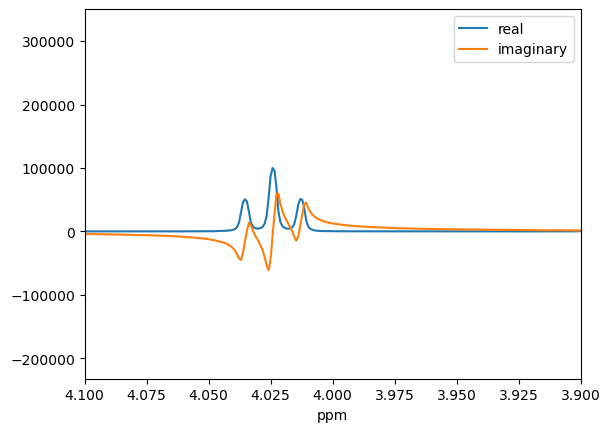

In [8]:
plt.plot(ppm, rrr[:, 0], label="real")
plt.plot(ppm, iii[:, 0], label="imaginary")
plt.legend()
plt.xlabel("ppm")
plt.gca().invert_xaxis()
plt.xlim(4.1, 3.9)

In [9]:
spec_cplx = rrr[:, :] + 1j * iii[:, :]
spec_cplx.shape, spec_cplx.dtype

((16384, 5), dtype('complex128'))

In [10]:
# create the FID by inverse Fourier transform
fid_cplx = np.zeros_like(spec_cplx, dtype=np.complex128)

for i in range(spec_cplx.shape[1]):
    fid_cplx[:, i] = ifft(spec_cplx[:, i])


Text(0, 0.5, 'Amplitude')

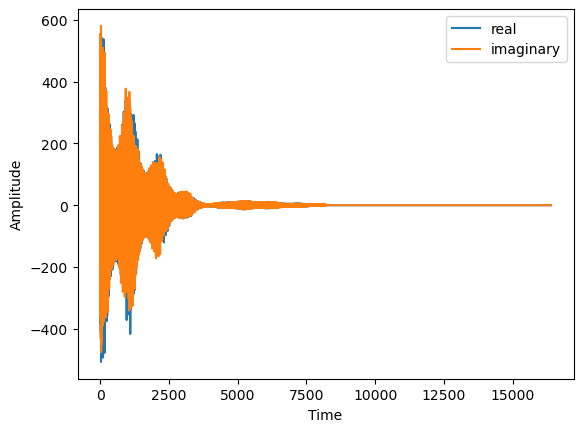

In [11]:
plt.plot(fid_cplx[:,0].real, label="real")
plt.plot(fid_cplx[:,0].imag, label="imaginary")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Amplitude")

In [12]:
# create  an interleaved 2D array of real and imaginary parts
num_pts, num_spectra = fid_cplx.shape
fid_interleaved = np.empty((num_pts * 2, num_spectra), dtype=fid_cplx.real.dtype)
fid_interleaved.shape, fid_interleaved.dtype

((32768, 5), dtype('float64'))

In [13]:
# add the real and imaginary parts to the interleaved array
for i in range(num_spectra):
    fid_interleaved[0::2, i] = fid_cplx[:, i].real
    fid_interleaved[1::2, i] = fid_cplx[:, i].imag

Text(0, 0.5, 'Amplitude')

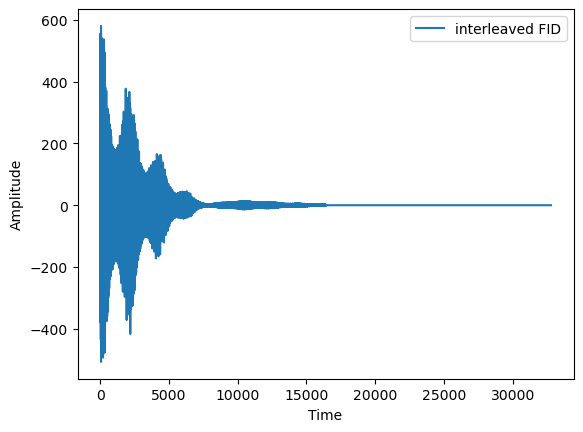

In [14]:
plt.plot(fid_interleaved[:,0], label="interleaved FID")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Amplitude")

In [15]:
fid_interleaved[0,0]

np.float64(400.367512026123)

In [16]:
from importlib.metadata import version
import sys

#print('Python path        :'+sys.executable)
print('Python version     :'+sys.version)
print('TopSpin Remote API :'+version('ts_remote_api'))
print('Bruker NMR API     :'+version('bruker_nmr_api'))

Python version     :3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:54:57) [Clang 14.0.6 ]
TopSpin Remote API :2.1.1
Bruker NMR API     :2.0.0
